# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [63]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
!pip install xlrd


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
print(os.getcwd())
print(os.listdir('../../../data/hw/hw_3/katsuhiro-kita/'))

# 2. Acquire and load your primary dataset
df_gpr=pd.read_excel('../../../data/hw/hw_3/katsuhiro-kita/data_gpr_export.xls')  

c:\Users\potsu\OneDrive\Documents\GitHub\datascience-publicpolicy-2026\notebooks\hw\hw_3
['data_gpr_export.xls', 'ebp_csv.csv']


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- *Write your source here*
  - https://www.matteoiacoviello.com/gpr.htm

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [64]:
# 1. Inspect data structure using pandas methods
df_gpr.info()
df_gpr.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1517 entries, 0 to 1516
Columns: 115 entries, month to var_label
dtypes: datetime64[ns](1), float64(111), int64(1), object(2)
memory usage: 1.3+ MB


,month,GPR,GPRT,GPRA,GPRH,GPRHT,GPRHA,SHARE_GPR,N10,SHARE_GPRH,...,GPRHC_TUN,GPRHC_TUR,GPRHC_TWN,GPRHC_UKR,GPRHC_USA,GPRHC_VEN,GPRHC_VNM,GPRHC_ZAF,var_name,var_label
0,1900-01-01,NaN,NaN,NaN,87.927849,64.717491,110.453522,NaN,NaN,3.171932,...,0.0,0.038840,0.0,0.0,2.718799,0.051787,0.012947,1.152253,month,Date (year/month)
1,1900-02-01,NaN,NaN,NaN,86.566490,71.936844,96.250488,NaN,NaN,3.122822,...,0.0,0.125471,0.0,0.0,2.732469,0.027882,0.000000,1.143176,GPR,Recent GPR (Index: 1985:2019=100)
2,1900-03-01,NaN,NaN,NaN,72.140701,57.475853,84.499428,NaN,NaN,2.602422,...,0.0,0.180366,0.0,0.0,2.151507,0.025767,0.000000,0.863180,GPRT,Recent GPR Threats (Index: 1985:2019=100)
3,1900-04-01,NaN,NaN,NaN,54.419449,37.326603,65.858208,NaN,NaN,1.963141,...,0.0,0.066774,0.0,0.0,1.776175,0.000000,0.000000,0.641026,GPRA,Recent GPR Acts (Index: 1985:2019=100)
4,1900-05-01,NaN,NaN,NaN,64.405197,48.200008,74.373955,NaN,NaN,2.323370,...,0.0,0.081522,0.0,0.0,1.970109,0.013587,0.000000,0.788043,GPRH,Historical GPR (Index: 1900:2019=100)


In [65]:
# 2. Rename columns and select a clean subset
df_gpr = df_gpr[['month', 'GPR', 'GPRT', 'GPRA']].rename(columns={'month': 'date','GPR': 'gpr_index','GPRT': 'gpr_threat', 'GPRA': 'gpr_act'})

df_gpr.head()

,date,gpr_index,gpr_threat,gpr_act
0,1900-01-01,NaN,NaN,NaN
1,1900-02-01,NaN,NaN,NaN
2,1900-03-01,NaN,NaN,NaN
3,1900-04-01,NaN,NaN,NaN
4,1900-05-01,NaN,NaN,NaN


In [66]:
# 3. Filter row or column filters if necessary

In [67]:
# 4. Handle missing values (NaNs) if necessary
df_gpr = df_gpr.dropna()
df_gpr.head()

,date,gpr_index,gpr_threat,gpr_act
1020,1985-01-01,102.173378,107.574173,89.647491
1021,1985-02-01,117.102020,126.442726,96.601669
1022,1985-03-01,124.778152,127.070854,116.987274
1023,1985-04-01,87.929001,94.640198,73.757797
1024,1985-05-01,103.262848,111.159782,92.276726


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [68]:
# 1. Load and clean the secondary dataset
df_ebp = pd.read_csv('../../../data/hw/hw_3/katsuhiro-kita/ebp_csv.csv').rename(columns={'date': 'date', 'gz_spread': 'gz_spread', 'ebp': 'ebp', 'est_prob': 'est_prob'}).dropna()
df_ebp.head()

,date,gz_spread,ebp,est_prob
0,1973-01-01,1.130771,-0.045310,0.187419
1,1973-02-01,1.075493,-0.056924,0.183542
2,1973-03-01,1.029968,-0.148198,0.154840
3,1973-04-01,0.982746,-0.208959,0.137472
4,1973-05-01,1.046494,-0.083356,0.174908


In [69]:
# 2. Merge your datasets on a common key
df_gpr['date'] = pd.to_datetime(df_gpr['date'])
df_ebp['date'] = pd.to_datetime(df_ebp['date'])

df_gpr_indexed = df_gpr.set_index('date')
df_ebp_indexed = df_ebp.set_index('date')

def merge(df_gpr, df_ebp):
    df_merge = pd.merge(df_gpr, df_ebp, left_index=True, right_index=True, how='inner')
    return df_merge


df_merge = merge(df_gpr_indexed, df_ebp_indexed)
df_merge.info()
df_merge.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 496 entries, 1985-01-01 to 2026-04-01
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   gpr_index   496 non-null    float64
 1   gpr_threat  496 non-null    float64
 2   gpr_act     496 non-null    float64
 3   gz_spread   496 non-null    float64
 4   ebp         496 non-null    float64
 5   est_prob    496 non-null    float64
dtypes: float64(6)
memory usage: 27.1 KB


,gpr_index,gpr_threat,gpr_act,gz_spread,ebp,est_prob
date,,,,,,
1985-01-01,102.173378,107.574173,89.647491,1.051938,-0.153047,0.153403
1985-02-01,117.102020,126.442726,96.601669,0.940588,-0.181907,0.145033
1985-03-01,124.778152,127.070854,116.987274,0.970689,0.052231,0.221934
1985-04-01,87.929001,94.640198,73.757797,1.061069,-0.078165,0.176583
1985-05-01,103.262848,111.159782,92.276726,1.199108,-0.290194,0.116403


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
    - I used the date column as the matching key.
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging
    - After performing the inner join, 496 matching rows (observations) were successfully retained.

- *Write your merge details here*
  - The final merged dataset combines the monthly Geopolitical Risk (GPR) indices with the Gilchrist-Zakrajšek (GZ) spread and Excess Bond Premium (EBP) metrics. The resulting panel spans from January 1985 to April 2026, containing 496 monthly observations across 6 variables (gpr_index, gpr_threat, gpr_act, gz_spread, ebp, est_prob), with no missing values (0 nulls). This provides a clean, perfectly aligned time-series dataset ready for macroeconomic and financial risk analysis.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [70]:
# Apply groupby aggregation or implement one of the backup grouping strategies
import numpy as np

df_merge['gpr_index'] = pd.to_numeric(df_merge['gpr_index'])
df_merge['gpr_threat'] = pd.to_numeric(df_merge['gpr_threat'])
df_merge['gpr_act'] = pd.to_numeric(df_merge['gpr_act'])

threshold_index = df_merge['gpr_index'].quantile(0.75)
df_merge['regime'] = np.where(df_merge['gpr_index'] >= threshold_index, 'High Risk', 'Normal')
df_grouped_index = df_merge.groupby('regime')[['gz_spread', 'ebp', 'est_prob']].mean()

threshold_threat = df_merge['gpr_threat'].quantile(0.75)
df_merge['regime'] = np.where(df_merge['gpr_threat'] >= threshold_threat, 'High Risk', 'Normal')
df_grouped_threat = df_merge.groupby('regime')[['gz_spread', 'ebp', 'est_prob']].mean()

threshold_act = df_merge['gpr_act'].quantile(0.75)
df_merge['regime'] = np.where(df_merge['gpr_act'] >= threshold_act, 'High Risk', 'Normal')
df_grouped_act = df_merge.groupby('regime')[['gz_spread', 'ebp', 'est_prob']].mean()

df_combined = pd.concat([df_grouped_index, df_grouped_threat, df_grouped_act], keys=['gpr_Index', 'gpr_Threat', 'gpr_Act'])

df_combined

gz_spread       ebp  est_prob
           regime                                  
gpr_Index  High Risk   1.810472  0.000819  0.231819
           Normal      1.950777  0.078690  0.248768
gpr_Threat High Risk   1.635924  0.006530  0.223735
           Normal      2.008959  0.076787  0.251462
gpr_Act    High Risk   1.911732  0.021542  0.242950
           Normal      1.917023  0.071783  0.245057

- *Extra Credit: Write your economic or policy related interpretation here*
  - In the present analysis (1985–2026), a counterintuitive finding emerged: the average values of the GZ spread, the Excess Bond Premium (EBP) and Estimated Probability of Default are higher during periods of low geopolitical risk (normal times) than during periods of high geopolitical risk (crises). This phenomenon can be attributed primarily to the following three factors.
  
  - First is the timing of historical, large-scale credit contractions (credit events). Significant events that caused historical spikes in the EBP, such as the 2008 Global Financial Crisis and the 2020 COVID-19 shock, occurred during periods classified as "normal times," when geopolitical risks were relatively subdued. It is highly probable that these events act as outliers, significantly inflating the average values for normal periods.
  
  - Second is the aggressive liquidity provision by central banks. In the event of a geopolitical crisis, central banks, such as the U.S. Federal Reserve (Fed), tend to implement rapid monetary easing—including interest rate cuts and liquidity injections—to prevent the shock from spilling over into the broader financial system. Consequently, ample liquidity is supplied to the market, supporting corporate financing and thereby suppressing the widening of credit spreads.
  
  - Third is the "flight to quality" into the U.S. market. When global uncertainty rises, international investment capital tends to seek refuge in the relatively safe and highly liquid U.S. market. As these safe-haven funds also flow into the U.S. corporate bond market, the domestic credit market tends to stabilize, which likely keeps the EBP suppressed even amid geopolitical crises.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

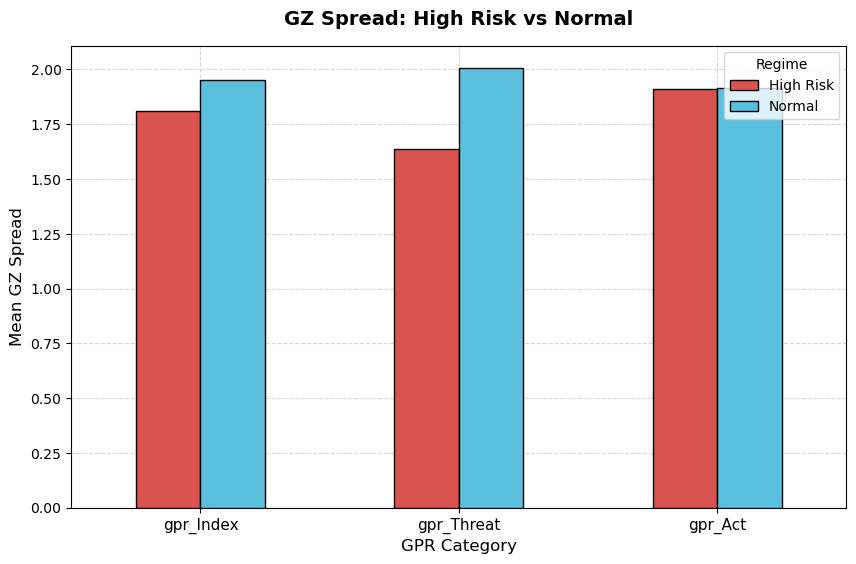

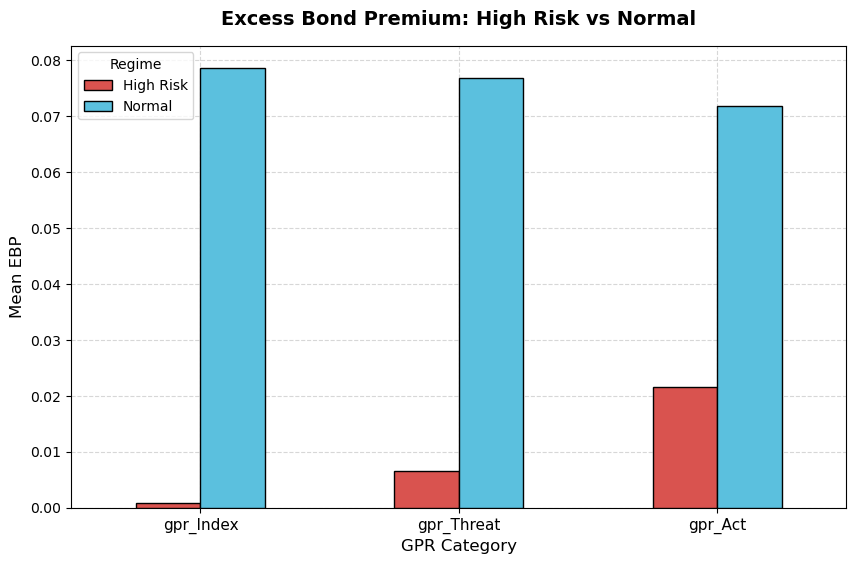

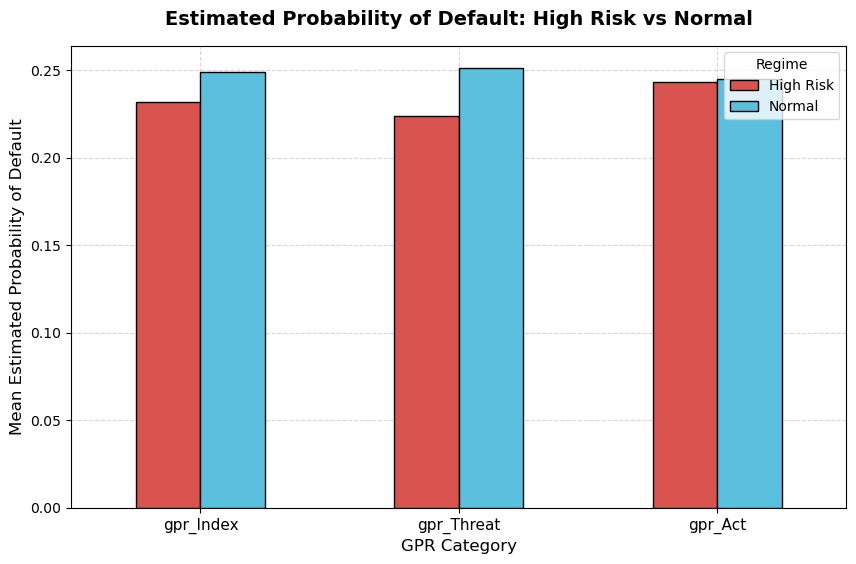

In [ ]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
df_plot = df_combined.unstack()
custom_colors = ['#d9534f', '#5bc0de'] 

fig1, ax1 = plt.subplots(figsize=(10, 6))

df_plot['gz_spread'].plot(kind='bar', ax=ax1, color=custom_colors, edgecolor='black', zorder=3)

ax1.set_title('GZ Spread: High Risk vs Normal', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('GPR Category', fontsize=12)
ax1.set_ylabel('Mean GZ Spread', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax1.tick_params(axis='x', rotation=0, labelsize=11)
ax1.legend(title='Regime', fontsize=10)

plt.show() 

fig2, ax2 = plt.subplots(figsize=(10, 6))

df_plot['ebp'].plot(kind='bar', ax=ax2, color=custom_colors, edgecolor='black', zorder=3)

ax2.set_title('Excess Bond Premium: High Risk vs Normal', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('GPR Category', fontsize=12)
ax2.set_ylabel('Mean EBP', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax2.tick_params(axis='x', rotation=0, labelsize=11)
ax2.legend(title='Regime', fontsize=10)

plt.show()

fig3, ax3 = plt.subplots(figsize=(10, 6))

df_plot['est_prob'].plot(kind='bar', ax=ax3, color=custom_colors, edgecolor='black', zorder=3)

ax3.set_title('Estimated Probability of Default: High Risk vs Normal', fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Geopolitical Risk Category', fontsize=12)
ax3.set_ylabel('Mean Estimated Probability of Default', fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax3.tick_params(axis='x', rotation=0, labelsize=11)
ax3.legend(title='Regime', fontsize=10)

plt.show()

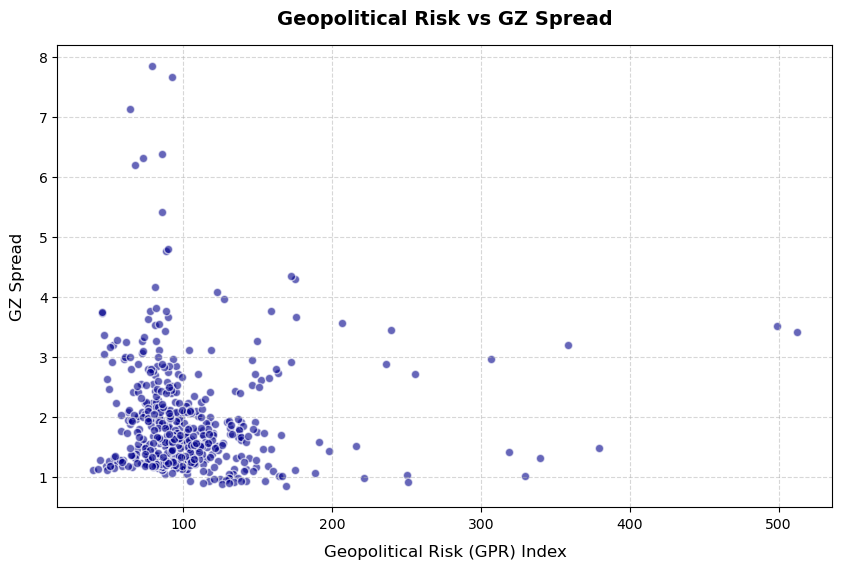

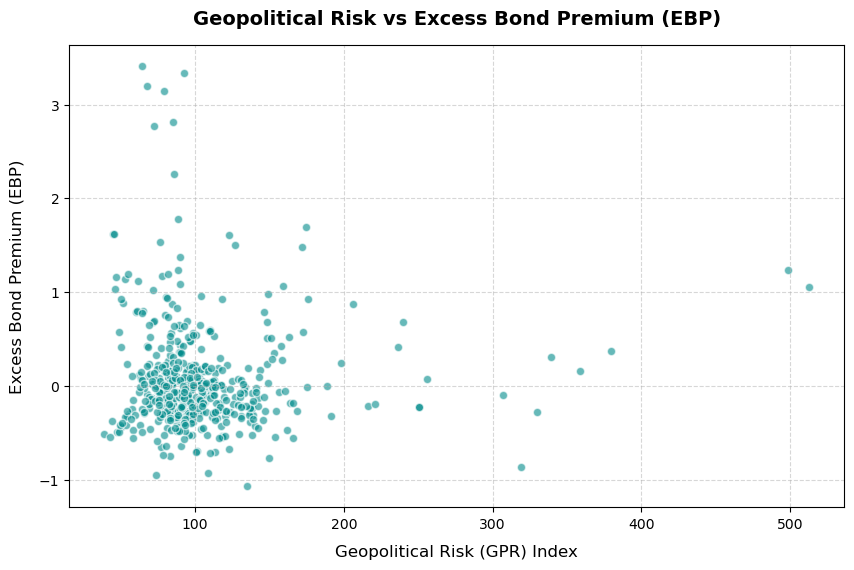

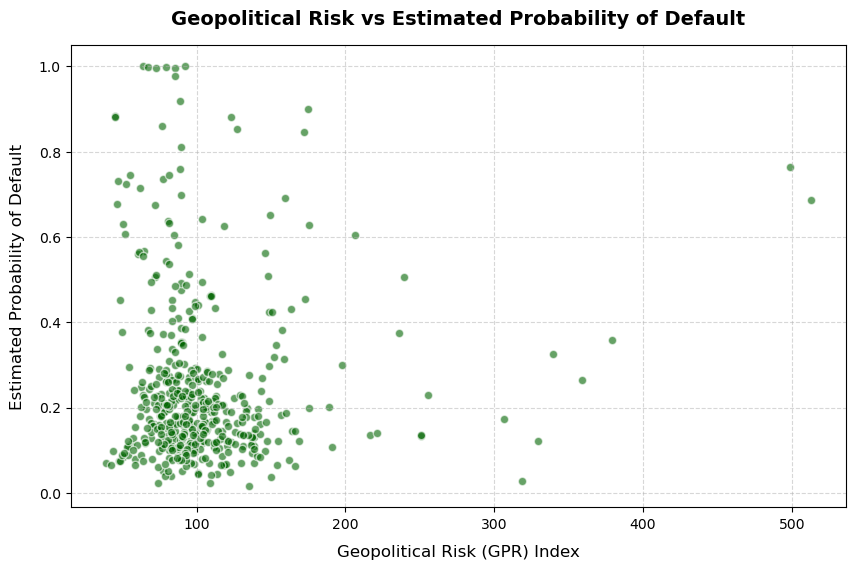

In [72]:
# Plot 2: Customized scatter plot of primary policy variables
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.scatter(df_merge['gpr_index'], df_merge['gz_spread'], alpha=0.6, color='darkblue', edgecolors='white')
ax1.set_title('Geopolitical Risk vs GZ Spread', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Geopolitical Risk (GPR) Index', fontsize=12, labelpad=10)
ax1.set_ylabel('GZ Spread', fontsize=12, labelpad=10)
ax1.grid(True, linestyle='--', alpha=0.5, zorder=0)
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.scatter(df_merge['gpr_index'], df_merge['ebp'], alpha=0.6, color='darkcyan', edgecolors='white')
ax2.set_title('Geopolitical Risk vs Excess Bond Premium (EBP)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Geopolitical Risk (GPR) Index', fontsize=12, labelpad=10)
ax2.set_ylabel('Excess Bond Premium (EBP)', fontsize=12, labelpad=10)
ax2.grid(True, linestyle='--', alpha=0.5, zorder=0)
plt.show()

fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.scatter(df_merge['gpr_index'], df_merge['est_prob'], alpha=0.6, color='darkgreen', edgecolors='white')
ax3.set_title('Geopolitical Risk vs Estimated Probability of Default', fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Geopolitical Risk (GPR) Index', fontsize=12, labelpad=10)
ax3.set_ylabel('Estimated Probability of Default', fontsize=12, labelpad=10)
ax3.grid(True, linestyle='--', alpha=0.5, zorder=0)
plt.show()

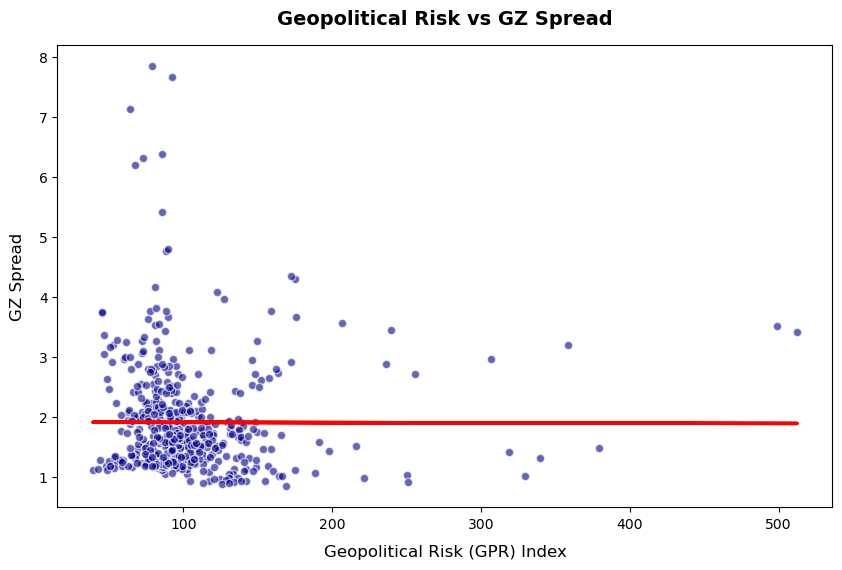

                            OLS Regression Results                            
Dep. Variable:              gz_spread   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                  0.002768
Date:                Wed, 03 Jun 2026   Prob (F-statistic):              0.958
Time:                        10:49:12   Log-Likelihood:                -662.90
No. Observations:                 496   AIC:                             1330.
Df Residuals:                     494   BIC:                             1338.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.9203      0.097     19.766      0.0

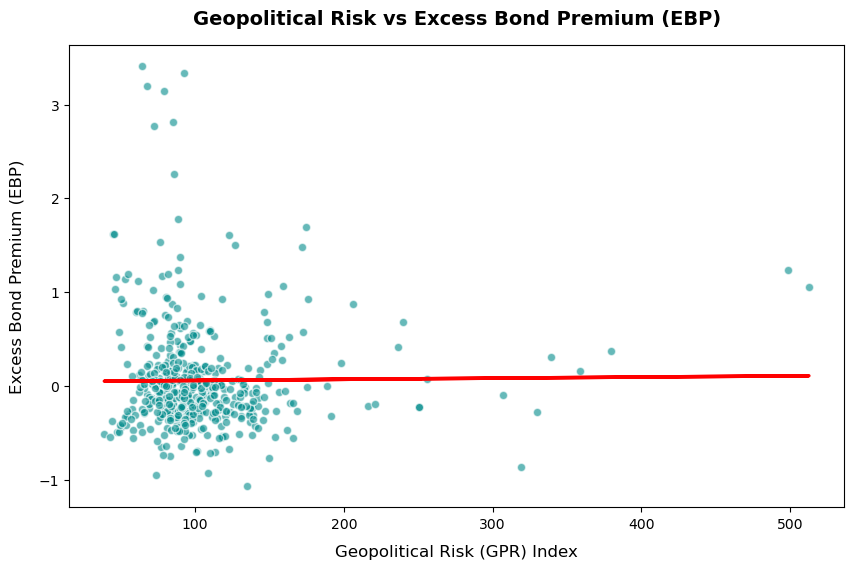

                            OLS Regression Results                            
Dep. Variable:                    ebp   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.05401
Date:                Wed, 03 Jun 2026   Prob (F-statistic):              0.816
Time:                        10:49:12   Log-Likelihood:                -424.01
No. Observations:                 496   AIC:                             852.0
Df Residuals:                     494   BIC:                             860.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0466      0.060      0.777      0.4

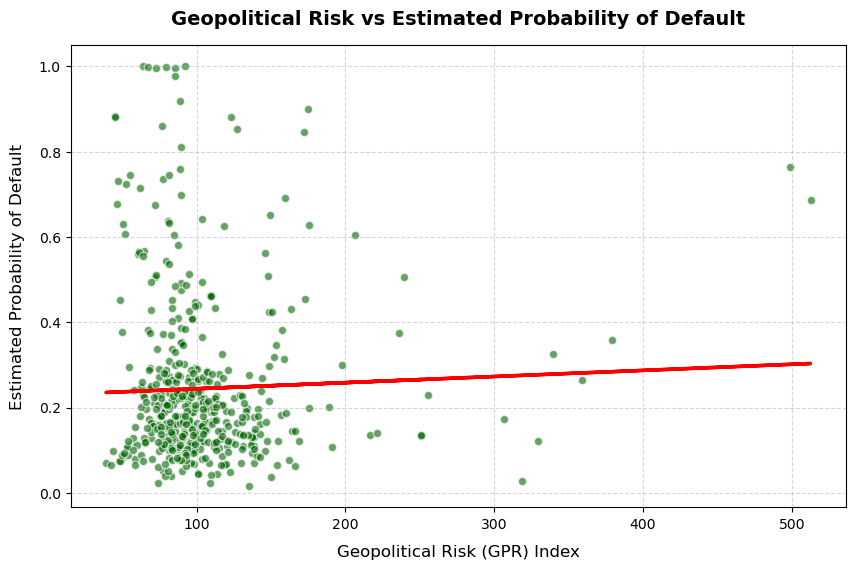

                            OLS Regression Results                            
Dep. Variable:               est_prob   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6432
Date:                Wed, 03 Jun 2026   Prob (F-statistic):              0.423
Time:                        10:49:13   Log-Likelihood:                 107.93
No. Observations:                 496   AIC:                            -211.9
Df Residuals:                     494   BIC:                            -203.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2296      0.021     11.182      0.0

In [73]:
# Fit a simple linear regression and overlay the line of best fit
import statsmodels.formula.api as smf
model_spread = smf.ols('gz_spread ~ gpr_index', data=df_merge).fit()
model_ebp = smf.ols('ebp ~ gpr_index', data=df_merge).fit()
model_est_prob = smf.ols('est_prob ~ gpr_index', data=df_merge).fit()

fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.scatter(df_merge['gpr_index'], df_merge['gz_spread'], alpha=0.6, color='darkblue', edgecolors='white')
x_pred1 = df_merge['gpr_index']
y_pred1 = model_spread.predict(x_pred1)
ax1.plot(x_pred1, y_pred1, color='red', linewidth=2.5, label='OLS Regression Line')

ax1.set_title('Geopolitical Risk vs GZ Spread', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Geopolitical Risk (GPR) Index', fontsize=12, labelpad=10)
ax1.set_ylabel('GZ Spread', fontsize=12, labelpad=10)
plt.show()

print(model_spread.summary())

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.scatter(df_merge['gpr_index'], df_merge['ebp'], alpha=0.6, color='darkcyan', edgecolors='white')
x_pred2 = df_merge['gpr_index']
y_pred2 = model_ebp.predict(x_pred2)
ax2.plot(x_pred2, y_pred2, color='red', linewidth=2.5, label='OLS Regression Line')

ax2.set_title('Geopolitical Risk vs Excess Bond Premium (EBP)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Geopolitical Risk (GPR) Index', fontsize=12, labelpad=10)
ax2.set_ylabel('Excess Bond Premium (EBP)', fontsize=12, labelpad=10)
plt.show()

print(model_ebp.summary())

fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.scatter(df_merge['gpr_index'], df_merge['est_prob'], alpha=0.6, color='darkgreen', edgecolors='white')
x_pred3 = df_merge['gpr_index']
y_pred3 = model_est_prob.predict(x_pred3)
ax3.plot(x_pred3, y_pred3, color='red', linewidth=2.5, label='OLS Regression Line')

ax3.set_title('Geopolitical Risk vs Estimated Probability of Default', fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Geopolitical Risk (GPR) Index', fontsize=12, labelpad=10)
ax3.set_ylabel('Estimated Probability of Default', fontsize=12, labelpad=10)
ax3.grid(True, linestyle='--', alpha=0.5, zorder=0)
plt.show()

print(model_est_prob.summary())


- *Extra Credit: Write your visualization and regression interpretations here*
  - The scatter plots from this analysis reveal that the GZ spread, the Excess Bond Premium (EBP), and the estimated probability of default (est_prob) are not consistently high during normal times (low GPR environments); rather, their overall averages are driven up by temporary anomalies (outliers) that occur during specific periods.

  - Conversely, when compared to a baseline that excludes these outliers from normal times, it can be observed that all three indicators trend at relatively higher levels during crises characterized by elevated geopolitical risk (high GPR environments). Interestingly, while est_prob follows this same general pattern, it exhibits a noticeably larger magnitude of increase during crises compared to the GZ spread and EBP. This indicates that the market does indeed react to the future uncertainty inherent in such crises, pushing up credit risk premiums to a certain extent, while perceiving a relatively stronger impact on fundamental default risk.

  - This heightened sensitivity is further supported by the slightly steeper slope of the regression line for est_prob. However, despite this relatively sharper response, the overall magnitude of the increase across all indicators remains strictly limited. This simultaneously suggests that geopolitical risk alone is insufficient to cause a severe credit contraction capable of triggering a systemic financial shock.

  

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.